# 11. Проверяем идеи второго решения

У другого агента получилось 0,8431, но его проверка не сравнима с нашей. Он резал отсортированные куки в соотношении 80/20 прямо внутри одного дня. Ещё важнее: Word2Vec обучался на сырых событиях, включая события после конца окна куки. Мы нашли таких строк 40 779. Сам агент это подтвердил. Поэтому новые признаки проверяем заново на наших трёх фолдах по целым дням

## Что именно пробуем

- **Категория:** самый частый `item_category` за сутки. При одинаковой частоте берём значение по алфавиту. Передаём как категориальный признак CatBoost. Самый частый город у нас уже был.
- **Время:** доля событий с 00:00 до 06:00 по часам `event_ts`, а также синус и косинус часа с наибольшим числом событий. Это часы записи, не обязательно местное время пользователя.
- **Курсор:** сначала воспроизводим исходный вариант с полной длиной пути, средней и максимальной скоростью. Затем считаем путь, шаг и скорость только для соседних точек с разницей времени от 1 секунды до 30 минут. Нулевые интервалы и длинные паузы оставляем отдельными долями.

На разрешённых событиях есть 1 929 пар точек с одинаковым временем и 11 191 пара с паузой больше получаса. Сырая скорость делит расстояние на `dt + 0.001`, поэтому одинаковые времена могут дать огромные числа. Сравним оба варианта вместо того, чтобы заранее выбирать по вкусу.

**Word2Vec пока не добавляем.** После усреднения векторов девяти типов событий каждая координата становится комбинацией уже имеющихся у нас долей этих типов. Порядок действий конкретной куки в среднем векторе исчезает

## Как сравниваем

Параметры CatBoost оставили такими же, как у ансамбля с курсором и городом. Сначала добавляем по одной группе к одиночной модели с контекстом, затем проверяем сочетания. После этого те же группы пробуем во всех трёх моделях ансамбля. На каждом фолде обучение видит только куки с уже закончившимся окном. Для сравнения показываем среднюю метрику по трём фолдам и одну метрику на всех проверочных куках вместе. Это разные числа, потому что P@R70 нелинейна.

Мы уже выбирали признаки по этим дням, поэтому даже такой опыт не даёт полностью независимой оценки будущего теста. Здесь он нужен для честного сравнения новых идей с этим ансамблем на **одних и тех же** куках

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run_solution.py").exists())
os.chdir(root)
sys.path.insert(0, str(root))
from utils.experiments.run_peer_features import main

Весь расчёт лежит в `utils/experiments/run_peer_features.py`, а сами признаки в `utils/peer_features.py`. Если таблицы ещё нет или хочешь повторить опыт с нуля, ячейка ниже запустит обучение. Для принудительного пересчёта поставь `REBUILD = True`

In [2]:
REBUILD = False
summary_path = root / "output" / "peer_feature_summary.csv"
if REBUILD or not summary_path.exists():
    main()

In [3]:
summary = pd.read_csv(summary_path)
display(summary.style.format({c: "{:.3f}" for c in summary.columns if c != "model"}))

,model,11–13 апреля,14–16 апреля,17–19 апреля,mean_fold,pooled
0,ensemble_category,0.725,0.708,0.742,0.725,0.731
1,current_rank,0.680,0.688,0.806,0.725,0.712
2,ensemble_time,0.673,0.710,0.785,0.723,0.703
3,current_context,0.657,0.714,0.778,0.716,0.695
4,ensemble_pointer_clean,0.673,0.703,0.767,0.714,0.709
5,ensemble_pointer_raw,0.648,0.717,0.767,0.711,0.708
6,category,0.690,0.714,0.718,0.707,0.702
7,time,0.603,0.742,0.758,0.701,0.704
8,ensemble_all_clean,0.645,0.688,0.767,0.700,0.694
9,pointer_clean,0.654,0.688,0.747,0.696,0.689


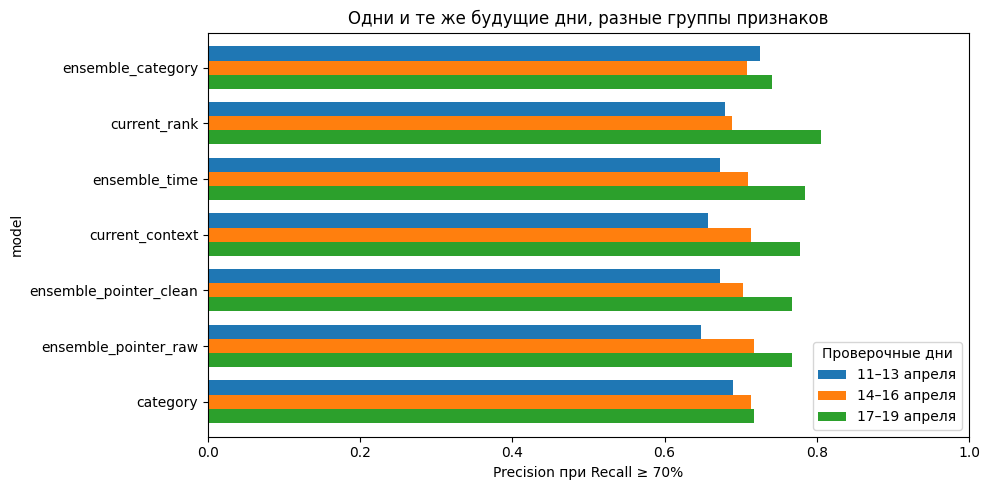

In [4]:
fold_columns = [c for c in summary.columns if "апреля" in c]
shown = summary.head(7).set_index("model")
ax = shown[fold_columns].plot.barh(figsize=(10, 5), width=.76)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Precision при Recall ≥ 70%")
ax.set_title("Одни и те же будущие дни, разные группы признаков")
ax.legend(title="Проверочные дни", loc="lower right")
plt.tight_layout()
plt.show()

## Что получилось

Лучший среди новых вариантов, три CatBoost с ведущей категорией, получил **0,7249** в среднем по трём фолдам. У ансамбля с курсором и городом **0,7246**. Разница меньше одной тысячной. На всех проверочных куках вместе категория дала **0,731** против **0,712**, но на последних 17–19 апреля просела с **0,806** до **0,742**. Поэтому назвать её устойчивым улучшением нельзя. Это скорее кандидат для следующей проверки.

Время активности дало ансамблю **0,723**, чистая кинематика **0,714**, а все новые группы вместе **0,700**. Исходная формула скорости с `dt + 0.001` хуже аккуратного варианта и в одиночной модели, и в ансамбле. Новые признаки не складываются в автоматический прирост: они могут менять решения у границы порога в обе стороны.

На этом шаге ансамбль не меняем. Если выбирать по одной только общей OOF-метрике, категория выглядит заманчиво. Но близкий к тесту период показывает заметный проигрыш, а мы уже смотрели на эти дни много раз. Рисковать итоговым файлом из-за такого сигнала не стоит

## Откуда взялись чужие 0,8+

Второй агент уточнил, что использовал **один и тот же** валидационный кусок для early stopping, подбора Optuna и итогового отчёта. Отдельного контрольного набора после выбора параметров не было. Это даёт оптимистичное число даже без проблемы с событиями после окна. Его 0,8431 не показывает, что Optuna сама по себе добавила столько качества. Точную долю каждого фактора без нового прогона определить нельзя.

Наш прошлый подбор Optuna тоже не дал прироста: на 17–19 апреля среднее рангов новых моделей получило 0,783 против 0,806 у старых настроек. Последний блок не является полностью слепым для всего проекта, поскольку мы уже смотрели на него при выборе признаков. Окончательный ответ даст только скрытый тест

## Файл с кандидатом

Скрипт сохраняет лучшую из **новых** схем в `output/peer_best_candidate.csv`. Она выбрана по среднему трёх фолдов. Этот файл нужен только для сравнения. Итоговый ответ мы выберем после следующих опытов с последовательностями событий

In [5]:
candidate_path = root / "output" / "peer_best_candidate.csv"
if candidate_path.exists():
    candidate = pd.read_csv(candidate_path)
    test = pd.read_csv(root / "data" / "test.csv")
    assert candidate.columns.tolist() == ["cookie_id", "score"]
    assert candidate.cookie_id.equals(test.cookie_id)
    assert candidate.score.notna().all() and candidate.score.between(0, 1).all()
    print(f"В файле {len(candidate)} кук, пропусков и лишних строк нет")
else:
    print("Локального файла кандидата нет. Для его создания запусти python3 -m utils.experiments.run_peer_features")

В файле 4909 кук, пропусков и лишних строк нет
